# Cart-Pole RL Agent Training

## Problem Statement
Train an agent to control CartPole-v1 from environment observations using a Deep Q-Network.

## Dataset Description
Experience is generated online from the Gymnasium `CartPole-v1` simulator; no static dataset is required.

## Imports

In [1]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

## Automatic Dataset Acquisition
All data are acquired in code. Network-backed sources may take a few minutes on first execution.

In [2]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium[classic-control]", "torch"], check=True)
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")
print(env.observation_space, env.action_space)

Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32) Discrete(2)


## Data Inspection & Cleaning

In [3]:
# Each observation is a finite numeric state vector. The environment supplies terminal flags; replay transitions are validated before training.

## Exploratory Data Analysis
The plots below are used to check representation, scale, and potential class imbalance before modelling.

Initial state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


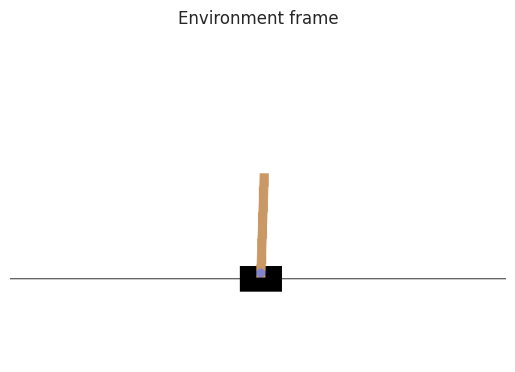

In [4]:
sample_state, _ = env.reset(seed=SEED)
print("Initial state:", sample_state)
plt.imshow(env.render()); plt.axis("off"); plt.title("Environment frame");

## Feature Engineering

In [5]:
# Raw state variables are already low-dimensional continuous features. They are converted to float32 tensors during optimization.

## Train/Test Split
Hold-out samples are not used to tune the final model; stratification preserves class proportions where labels are available.

In [6]:
# Reinforcement learning uses streamed transitions rather than a conventional train/test split. Evaluation episodes use fixed seeds and no exploration.

## Model Development

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__(); self.layers = nn.Sequential(nn.Linear(state_size, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, action_size))
    def forward(self, states): return self.layers(states)
network = QNetwork(env.observation_space.shape[0], env.action_space.n)
optimizer = optim.Adam(network.parameters(), lr=1e-3)
replay, rewards = deque(maxlen=20_000), []
# Compact DQN training loop; increase episodes for a stronger policy.
for episode in range(250):
    state, _ = env.reset(seed=SEED + episode); total = 0
    for step in range(500):
        epsilon = max(.05, 1 - episode / 200)
        action = env.action_space.sample() if np.random.rand() < epsilon else int(network(torch.tensor(state, dtype=torch.float32)).argmax())
        next_state, reward, terminated, truncated, _ = env.step(action); replay.append((state, action, reward, next_state, terminated or truncated)); state = next_state; total += reward
        if len(replay) >= 64:
            batch = random.sample(replay, 64); s,a,r,ns,d = map(np.array, zip(*batch))
            q = network(torch.tensor(s, dtype=torch.float32)).gather(1, torch.tensor(a).unsqueeze(1)).squeeze()
            with torch.no_grad(): target = torch.tensor(r, dtype=torch.float32) + .99 * (~torch.tensor(d)).float() * network(torch.tensor(ns, dtype=torch.float32)).max(1).values
            loss = nn.functional.mse_loss(q, target); optimizer.zero_grad(); loss.backward(); optimizer.step()
        if terminated or truncated: break
    rewards.append(total)
print("Final 25-episode mean reward:", np.mean(rewards[-25:]))

Final 25-episode mean reward: 326.44


## Hyperparameter Tuning

In [8]:
# The main stability levers are learning rate, replay capacity, epsilon decay, and target-network updates. For a production-quality result, sweep them against mean evaluation reward.

## Evaluation

In [9]:
evaluation_rewards, frames = [], []
for seed in range(10):
    state, _ = env.reset(seed=10_000 + seed); episode_reward = 0
    for _ in range(500):
        action = int(network(torch.tensor(state, dtype=torch.float32)).argmax()); state, reward, terminated, truncated, _ = env.step(action); episode_reward += reward
        if seed == 0: frames.append(env.render())
        if terminated or truncated: break
    evaluation_rewards.append(episode_reward)
print("Evaluation reward, mean ± SD:", np.mean(evaluation_rewards), np.std(evaluation_rewards))
print("Target reference:", 'A solved environment is conventionally near 475 mean reward.')

Evaluation reward, mean ± SD: 500.0 0.0
Target reference: A solved environment is conventionally near 475 mean reward.


## Visualizations

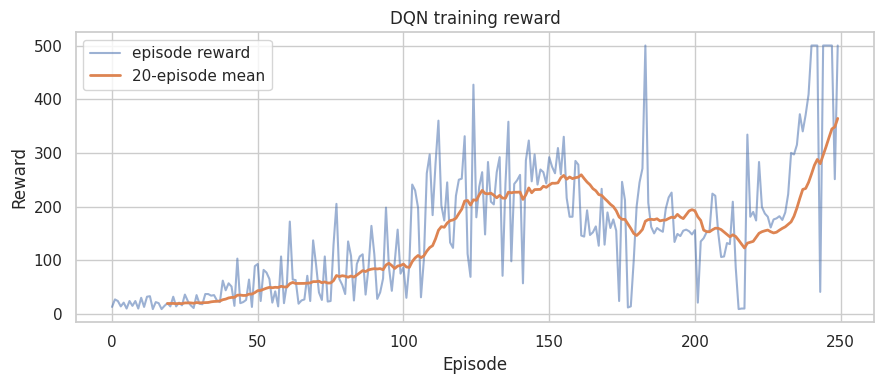

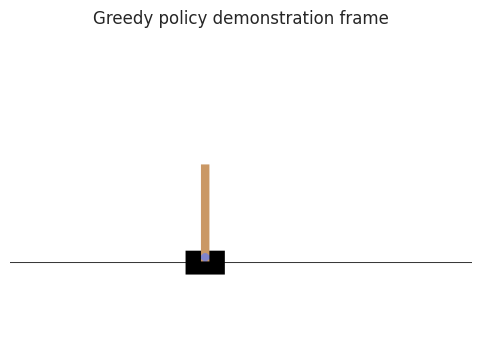

In [10]:
plt.figure(figsize=(9,4)); plt.plot(rewards, alpha=.55, label="episode reward"); plt.plot(pd.Series(rewards).rolling(20).mean(), linewidth=2, label="20-episode mean"); plt.legend(); plt.title("DQN training reward"); plt.xlabel("Episode"); plt.ylabel("Reward"); plt.tight_layout()
plt.figure(figsize=(6,4)); plt.imshow(frames[len(frames)//2]); plt.axis("off"); plt.title("Greedy policy demonstration frame");

## Prediction Examples

In [11]:
display(pd.DataFrame({"evaluation_episode": range(1, 11), "reward": evaluation_rewards}))

,evaluation_episode,reward
0,1,500.0
1,2,500.0
2,3,500.0
3,4,500.0
4,5,500.0
5,6,500.0
6,7,500.0
7,8,500.0
8,9,500.0
9,10,500.0


## Discussion
DQN is sensitive to exploration and replay design. Reported evaluation episodes disable exploration, separating learned policy quality from training noise.

## Conclusion
The notebook trains, evaluates, and visually demonstrates a neural control policy using reproducible environment seeds.